In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load file
df = pd.read_csv("data.csv")

# rename if needed
df.columns = ["time", "bme", "dht"]

In [3]:
df["error"] = df["dht"] - df["bme"]

In [4]:
bias = df["error"].mean()
R = df["error"].var()

print("Bias:", bias)
print("R (variance):", R)

Bias: 0.24911322248614365
R (variance): 0.00276181205165172


In [5]:
df["dht_corr"] = df["dht"] - bias

In [6]:
Q = 0.00001

In [7]:
# parameters (use your computed values)
R = R          # from your data
Q = 0.00001    # your tuned value
bias = bias    # from your data

# initial values
x = df["dht"].iloc[0] - bias
P = 1.0

kf_est = []
kf_var = []
kf_conf = []
kf_innov = []

for z_raw in df["dht"]:
    # bias correction
    z = z_raw - bias

    # --- Prediction ---
    P = P + Q

    # --- Kalman Gain ---
    K = P / (P + R)

    # --- Innovation ---
    innovation = z - x

    # --- Update ---
    x = x + K * innovation
    P = (1 - K) * P

    # --- Store ---
    kf_est.append(x)
    kf_var.append(P)
    kf_innov.append(innovation)

    # --- Confidence (improved version) ---
    var_norm = P / (P + R)
    innov_norm = abs(innovation)

    conf = np.exp(-2.0 * var_norm) * np.exp(-0.5 * innov_norm)
    conf = np.clip(conf * 100.0, 0, 100)

    kf_conf.append(conf)

# add to dataframe
df["kf"] = kf_est
df["kf_var"] = kf_var
df["kf_conf"] = kf_conf
df["kf_innov"] = kf_innov

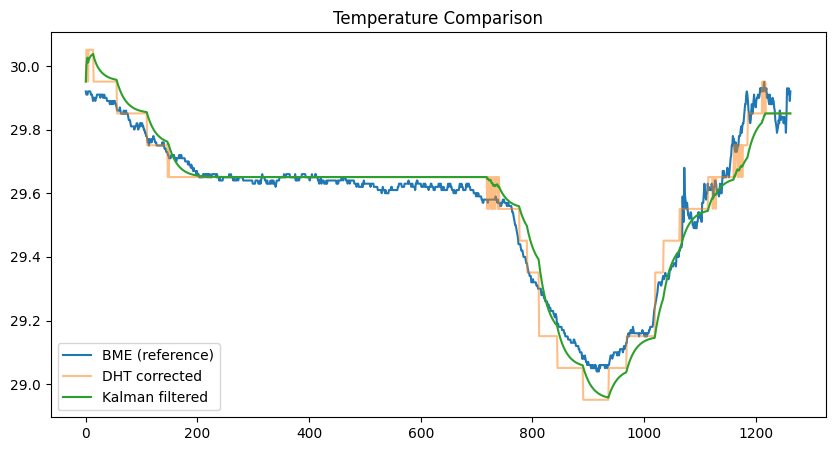

In [14]:
plt.figure(figsize=(10,5))

plt.plot(df["bme"], label="BME (reference)")
plt.plot(df["dht_corr"], label="DHT corrected", alpha=0.5)
plt.plot(df["kf"], label="Kalman filtered")

plt.legend()
plt.title("Temperature Comparison")
plt.show()

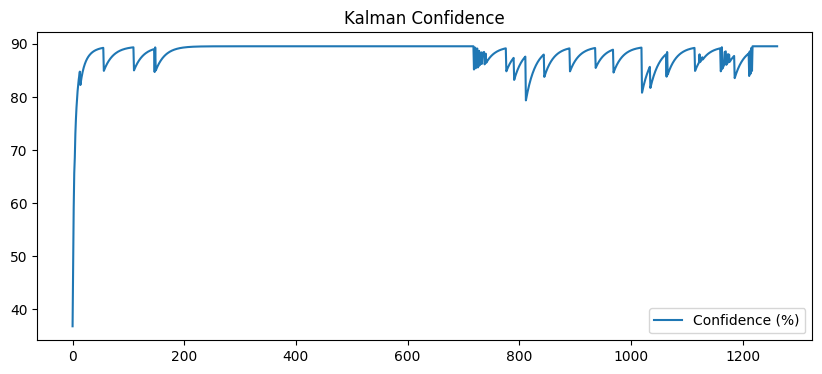

In [16]:
plt.figure(figsize=(10,4))
plt.plot(df["kf_conf"], label="Confidence (%)")
plt.legend()
plt.title("Kalman Confidence")
plt.show()

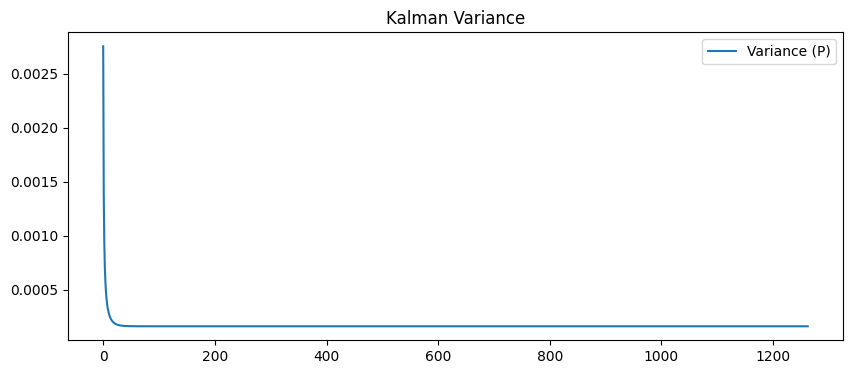

In [15]:
plt.figure(figsize=(10,4))
plt.plot(df["kf_var"], label="Variance (P)")
plt.legend()
plt.title("Kalman Variance")
plt.show()

In [9]:
df["raw_error"] = df["dht_corr"] - df["bme"]
df["kf_error"] = df["kf"] - df["bme"]

print("Raw RMSE:", np.sqrt(np.mean(df["raw_error"]**2)))
print("KF RMSE:", np.sqrt(np.mean(df["kf_error"]**2)))

Raw RMSE: 0.052532136295531946
KF RMSE: 0.05403591832149917


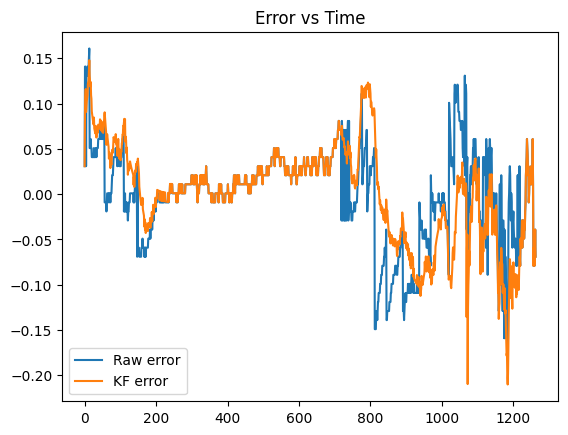

In [10]:
plt.plot(df["raw_error"], label="Raw error")
plt.plot(df["kf_error"], label="KF error")
plt.legend()
plt.title("Error vs Time")
plt.show()

In [11]:
print("R =", df['error'].var())

R = 0.00276181205165172


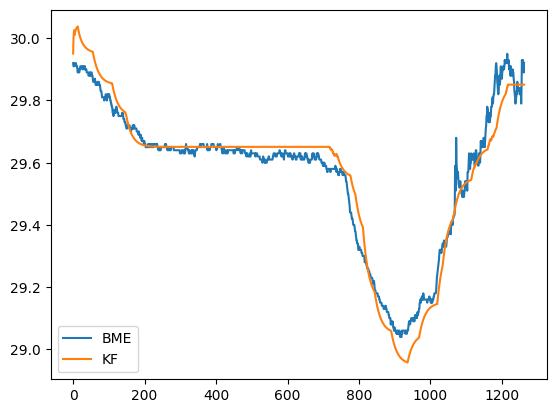

In [12]:
plt.plot(df["bme"], label="BME")
plt.plot(df["kf"], label="KF")
plt.legend()
plt.show()